# SCF in QEpy: two approaches, and density residuals

QEpy can run a self-consistent field (SCF) in two ways:

| | Call | Who drives the loop | Density each step |
|---|---|---|---|
| **A. Traditional** | `driver.scf()` | Quantum ESPRESSO | no |
| **B. Iterative** | `diagonalize()` then `mix()` | your Python loop | yes |

Use **A** when you only need a converged energy. Use **B** when you want to watch the charge density ρ change from one iteration to the next.

Run the cells once and read the prints and plot. **Nothing is saved** — no logs, CSV, or figures on disk.

After each mix in B we record:

- `scf_err` — QE’s SCF error (`get_scf_error()`), compared with `conv_thr`
- `drho_max` — max |ρᵢ − ρᵢ₋₁| on the grid
- `drho_l1` — mean |ρᵢ − ρᵢ₋₁|

A healthy run: all three decay together. If `scf_err` drops while `drho_max` stays large, the density has not settled.

**Setup:** QEpy, ASE, NumPy, Matplotlib. Pseudopotentials come from [KSPP](https://github.com/Quantum-MultiScale/KSPP) via `ksppresolver=True`. Swap `atoms` below for any system.

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install qepy f90wrap==0.2.16
!pip install dftpy
!pip install matplotlib

## 1. Settings and system

Replace `atoms` with any ASE `Atoms` object. `Driver` fills `nat`, cell, and positions from it. The example is 2×2 graphene.

In [1]:
import time

import numpy as np
from ase.build import graphene
from qepy.driver import Driver

atoms = graphene(size=(2, 2, 1), vacuum=10.0)

qe_options = {}

qe_options["&control"] = {}
qe_options["&control"]["calculation"] = "'scf'"
qe_options["&control"]["restart_mode"] = "'from_scratch'"
qe_options["&control"]["prefix"] = "'scf'"
qe_options["&control"]["disk_io"] = "'none'"

qe_options["&system"] = {}
qe_options["&system"]["ibrav"] = 0
qe_options["&system"]["ecutwfc"] = 40.0
qe_options["&system"]["occupations"] = "'smearing'"
qe_options["&system"]["smearing"] = "'gaussian'"
qe_options["&system"]["degauss"] = 0.01

qe_options["&electrons"] = {}
qe_options["&electrons"]["conv_thr"] = 1.0e-8
qe_options["&electrons"]["mixing_beta"] = 0.4
qe_options["&electrons"]["electron_maxstep"] = 150

qe_options["k_points automatic"] = ["2 2 2 0 0 0"]

print(atoms)

Atoms(symbols='C8', pbc=[True, True, False], cell=[[4.92, 0.0, 0.0], [-2.46, 4.260844986619438, 0.0], [0.0, -0.0, 20.0]])


## 2. Resolve pseudopotentials with KSPP

`ksppresolver=True` downloads (and caches) UPFs from [KSPP](https://github.com/Quantum-MultiScale/KSPP). You do not set `pseudo_dir` or `atomic_species`.

Default table: `ultrasoft/gbrv-v1.5`. Other libraries, via `table=`:

| Type | `table=` |
|---|---|
| GBRV ultrasoft (default) | `ultrasoft/gbrv-v1.5` |
| ONCV (PseudoDojo) | `norm-conserving/nc-sr-05` or `nc-sr-04` |
| JTH PAW | `paw/jth-v1.1` |

Needs network the first time; after that the cache is local. See `qepy_kspp_pseudo_setup.ipynb` for more tables.

In [2]:
# Change TABLE to switch PP library (None → KSPP default GBRV ultrasoft)
TABLE = "ultrasoft/gbrv-v1.5"

## 3. Approach A — traditional SCF

`iterative=False` (the default): QE runs the full loop internally. You get a final energy, not ρ at each step.

In [10]:
driver = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    logfile="tmp1.out"
)
t0 = time.perf_counter()
driver.scf()
t_scf = time.perf_counter() - t0

E_scf = float(driver.get_energy())
conv_scf = bool(driver.check_convergence())
driver.stop()

print(f"traditional scf()  conv={conv_scf}  E={E_scf:.10f} Ry  wall={t_scf:.3f} s")

traditional scf()  conv=True  E=-91.9330483552 Ry  wall=29.181 s


## 4. Approach B — iterative SCF and density residuals

Same algorithm, driven from Python:

1. `diagonalize()` — KS solve → new density
2. `mix()` — mix with the previous density (`mixing_beta`)

Iteration 1 has no previous ρ, so `drho_*` starts at step 2. Stop when `check_convergence()` is true (QE `scf_err` < `conv_thr`).

In [8]:
driver = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    iterative=True,
    logfile="tmp2.out"
)

rho_prev = None
iters, scf_err, drho_max, drho_l1 = [], [], [], []
t0 = time.perf_counter()
converged = False

print(f"{'iter':>4}  {'scf_err':>12}  {'drho_max':>12}  {'drho_l1':>12}")
for i in range(1, qe_options["&electrons"]["electron_maxstep"] + 1):
    driver.diagonalize()
    driver.mix()

    rho = driver.get_density().copy()
    if rho_prev is None:
        dmax = dl1 = np.nan
    else:
        drho = np.abs(rho - rho_prev)
        dmax, dl1 = float(np.max(drho)), float(np.mean(drho))
    rho_prev = rho

    err = float(driver.get_scf_error())
    iters.append(i)
    scf_err.append(err)
    drho_max.append(dmax)
    drho_l1.append(dl1)
    print(f"[{i:03d}]  {err:12.3e}  {dmax:12.3e}  {dl1:12.3e}")

    if driver.check_convergence():
        converged = True
        break

t_iter = time.perf_counter() - t0
E_iter = float(driver.get_energy())
driver.stop()

print(f"iterative  conv={converged}  iters={len(iters)}  E={E_iter:.10f} Ry  wall={t_iter:.3f} s")
print(f"ΔE vs traditional scf() = {E_iter - E_scf:.3e} Ry")

iter       scf_err      drho_max       drho_l1
[001]     2.779e-01           nan           nan
[002]     2.812e-02     1.252e-02     2.106e-04
[003]     1.901e-03     7.649e-03     1.124e-04
[004]     1.344e-04     5.886e-04     1.471e-05
[005]     2.171e-06     1.122e-04     1.886e-06
[006]     9.266e-08     4.083e-05     6.092e-07
[007]     1.642e-07     2.023e-05     4.337e-07
[008]     1.243e-08     7.089e-06     1.439e-07
[009]     5.797e-11     9.932e-07     1.751e-08
iterative  conv=True  iters=9  E=-91.9330483555 Ry  wall=30.164 s
ΔE vs traditional scf() = -6.230e-11 Ry


## 5. Plot and read the residuals

- All three curves should fall (log scale) after a few steps.
- `drho_max` ≫ `drho_l1` is normal (a few grid points, often near nuclei, move more).
- Oscillation or a stall above `conv_thr`: lower `mixing_beta`, or tighten the k-grid / cutoff.
- Energies from A and B should match if both converged.

final scf_err  = 5.797e-11   conv_thr = 1.0e-08
final drho_max = 9.932e-07
final drho_l1  = 1.751e-08


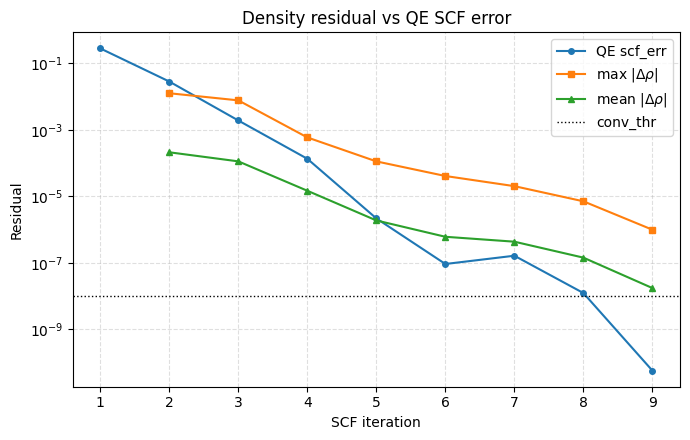

In [11]:
import matplotlib.pyplot as plt

dmax = np.asarray(drho_max)
ok = ~np.isnan(dmax)

print(f"final scf_err  = {scf_err[-1]:.3e}   conv_thr = {qe_options['&electrons']['conv_thr']:.1e}")
if ok.any():
    print(f"final drho_max = {dmax[ok][-1]:.3e}")
    print(f"final drho_l1  = {np.asarray(drho_l1)[ok][-1]:.3e}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(iters, scf_err, "o-", ms=4, label="QE scf_err")
if ok.any():
    ax.semilogy(np.asarray(iters)[ok], dmax[ok], "s-", ms=4, label=r"max $|\Delta\rho|$")
    ax.semilogy(np.asarray(iters)[ok], np.asarray(drho_l1)[ok], "^-", ms=4, label=r"mean $|\Delta\rho|$")
ax.axhline(qe_options["&electrons"]["conv_thr"], color="k", ls=":", lw=1, label="conv_thr")
ax.set_xlabel("SCF iteration")
ax.set_ylabel("Residual")
ax.set_title("Density residual vs QE SCF error")
ax.minorticks_off()
ax.grid(True, which="major", ls="--", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()